<a href="https://colab.research.google.com/github/AdrienBangs/Pre-programming-class-UE/blob/main/Stick_market.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt


# 1) Load & merge
bases = pd.read_csv("M-0866X-Bases.csv")
descr = pd.read_csv("M-0866X-Descriptors.csv")

bases.columns = bases.columns.str.strip()
descr.columns = descr.columns.str.strip()

df = pd.merge(bases, descr, on="Obs", how="left")# Keep customers only
df = df[df["Cust"] == 1].copy()

# After merge & filtering customers
print("\nDataFrame shape:", df.shape)

print("\nFirst 5 rows:")
display(df.head())   # use display()

print("\nColumn names:")
print(df.columns.tolist())


# 2) Use BASES only (B1–B4)
base_cols = ["B1", "B2", "B3", "B4"]

# Convert 5 = "Don't know" to missing
for c in base_cols:
    df.loc[df[c] == 5, c] = np.nan

X_in = df[base_cols].astype(float)

# 3) Impute + Scale
imp = SimpleImputer(strategy="median")
scl = StandardScaler()

X = scl.fit_transform(imp.fit_transform(X_in))





DataFrame shape: (203, 105)

First 5 rows:


,Obs,Cust,B1,B2,B3,B4,D1,D2.1,D2.2,D2.3,...,D18.1,D18.2,D18.3,D18.4,D18.5,D18.6,D18.7,D18.8,D18.9,D18.10
192,268,1,2,2,2,2,1,4.0,3.0,3.0,...,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,NaN
193,269,1,3,3,2,1,1,5.0,3.0,NaN,...,5.0,2.0,3.0,2.0,2.0,3.0,3.0,2.0,3.0,Sadly it is not close to where I live or work.
194,270,1,2,3,1,1,1,2.0,5.0,1.0,...,2.0,2.0,2.0,1.0,1.0,1.0,1.0,1.0,2.0,NaN
195,271,1,1,3,2,1,1,4.0,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
196,272,1,3,3,2,3,1,5.0,1.0,1.0,...,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,3.0,NaN



Column names:
['Obs', 'Cust', 'B1', 'B2', 'B3', 'B4', 'D1', 'D2.1', 'D2.2', 'D2.3', 'D2.4', 'D2.5', 'D2.6', 'D3.1', 'D3.2', 'D3.3', 'D3.4', 'D3.5', 'D4.1', 'D4.2', 'D4.3', 'D4.4', 'D4.5', 'D4.6', 'D4.7', 'D4.8', 'D4.9', 'D4.10', 'D5', 'D6', 'D7', 'D8', 'D9.1', 'D9.2', 'D9.3', 'D10.1', 'D10.2', 'D10.3', 'D10.4', 'D10.5', 'D10.6', 'D10.7', 'D10.8', 'D11.1', 'D11.2', 'D11.3', 'D11.4', 'D11.5', 'D11.6', 'D11.7', 'D11.8', 'D11.9', 'D11.10', 'D11.11', 'D12.1', 'D12.2', 'D12.3', 'D12.4', 'D12.5', 'D12.6', 'D12.7', 'D12.8', 'D12.9', 'D12.10', 'D12.11', 'D12.12', 'D12.13', 'D12.14', 'D12.15', 'D12.16', 'D12.17', 'D12.18', 'D13', 'D14.1', 'D14.2', 'D14.3', 'D14.4', 'D14.5', 'D14.6', 'D14.7', 'D15.1', 'D15.2', 'D15.3', 'D15.4', 'D15.5', 'D15.6', 'D15.7', 'D16', 'D17.1', 'D17.2', 'D17.3', 'D17.4', 'D17.5', 'D17.6', 'D17.7', 'D18.1', 'D18.2', 'D18.3', 'D18.4', 'D18.5', 'D18.6', 'D18.7', 'D18.8', 'D18.9', 'D18.10']


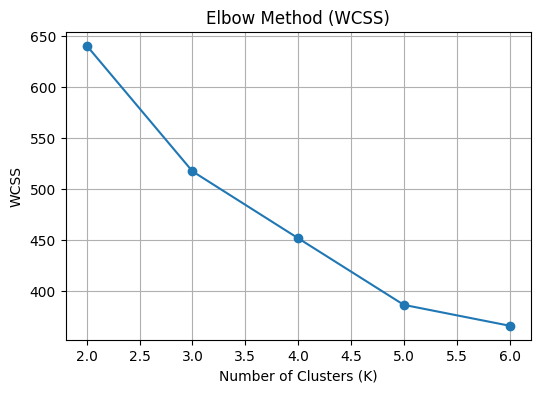

K=2, Silhouette=0.223
K=3, Silhouette=0.241
K=4, Silhouette=0.251
K=5, Silhouette=0.277
K=6, Silhouette=0.271

Best K = 5


In [ ]:
# 4A) Elbow Method (WCSS)
wcss = []

K_range = range(2, 7)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X)
    wcss.append(km.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, wcss, marker="o")
plt.title("Elbow Method (WCSS)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.grid(True)
plt.show()

# 4) Pick best K (2–6)
best_k, best_score = None, -1

for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"K={k}, Silhouette={score:.3f}")
    if score > best_score:
        best_k, best_score = k, score

print("\nBest K =", best_k)

# 5) Fit best model
kmeans = KMeans(n_clusters=best_k, random_state=42)
clusters = kmeans.fit_predict(X)
df["Cluster"] = clusters



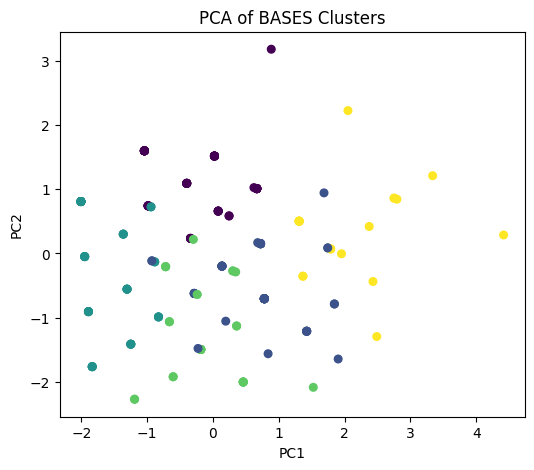

In [ ]:
# 6) PCA plot
pca = PCA(n_components=2)
pc = pca.fit_transform(X)

plt.figure(figsize=(6,5))
plt.scatter(pc[:,0], pc[:,1], c=clusters, cmap="viridis", s=30)
plt.title("PCA of BASES Clusters")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()



In [ ]:
# 7) Profile BASES (simple profile)
print("\nCluster sizes:")
print(df["Cluster"].value_counts())

print("\nBASES means per cluster:")
print(df.groupby("Cluster")[base_cols].mean())




Cluster sizes:
Cluster
0    59
1    55
2    40
3    28
4    21
Name: count, dtype: int64

BASES means per cluster:
               B1        B2        B3        B4
Cluster                                        
0        1.457627  3.711864  2.050847  1.423729
1        1.909091  2.145455  2.072727  1.890909
2        1.275000  2.850000  1.000000  1.175000
3        2.642857  2.500000  1.142857  1.571429
4        2.666667  3.428571  2.285714  2.619048


In [ ]:
# 8) Profile DESCRIPTORS (simple enrichment)
d17_cols = [c for c in df.columns if c.startswith("D17.")]
d4_cols  = [c for c in df.columns if c.startswith("D4.")]
d18_cols = [c for c in df.columns if c.startswith("D18.")]

print("\nOccasions (D17) means:")
print(df.groupby("Cluster")[d17_cols].mean(numeric_only=True))

print("\nImportance (D4) means:")
print(df.groupby("Cluster")[d4_cols].mean(numeric_only=True))

print("\nComparative Ratings (D18) means:")
print(df.groupby("Cluster")[d18_cols].mean(numeric_only=True))


Occasions (D17) means:
            D17.1     D17.2     D17.3     D17.4     D17.5     D17.6
Cluster                                                            
0        3.180000  3.229167  4.291667  4.583333  5.510638  5.574468
1        3.306122  3.510638  3.953488  3.954545  5.209302  5.928571
2        3.444444  3.230769  3.440000  3.869565  5.909091  5.772727
3        3.045455  2.583333  4.100000  4.315789  5.500000  5.722222
4        3.750000  3.800000  4.000000  2.411765  5.000000  5.642857

Importance (D4) means:
             D4.1      D4.2      D4.3      D4.4      D4.5      D4.6      D4.7  \
Cluster                                                                         
0        1.482143  1.678571  1.285714  1.571429  1.107143  1.589286  1.875000   
1        1.377358  1.584906  1.320755  1.509434  1.056604  1.509434  1.641509   
2        1.583333  1.823529  1.428571  1.428571  1.029412  1.714286  1.777778   
3        1.615385  1.730769  1.346154  1.423077  1.076923  1.576923  1.

In [ ]:
#Logistic Regression
#Select Features & Target
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

features = ["B1", "B2", "B3", "B4"]

X = df[features]
y = df["Cluster"]

#Handle Missing Values + Scale
from sklearn.impute import SimpleImputer

imp = SimpleImputer(strategy="median")
scl = StandardScaler()

X_imputed = imp.fit_transform(X)
X_scaled = scl.fit_transform(X_imputed)

#Train / Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [ ]:
#Fit Logistic Regression
log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
#Model Performance
from sklearn.metrics import accuracy_score, classification_report

y_pred = log_reg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

#Feature Importance
feature_importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": log_reg.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

print("\nFeature Importance (Logistic Regression):")
print(feature_importance)


Accuracy: 0.9512195121951219

Classification Report:
               precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.92      1.00      0.96        11
           2       1.00      1.00      1.00         8
           3       1.00      0.83      0.91         6
           4       1.00      0.75      0.86         4

    accuracy                           0.95        41
   macro avg       0.97      0.92      0.94        41
weighted avg       0.96      0.95      0.95        41


Feature Importance (Logistic Regression):
  Feature  Coefficient
1      B2     1.874931
2      B3     1.586301
3      B4    -1.071663
0      B1    -1.487996


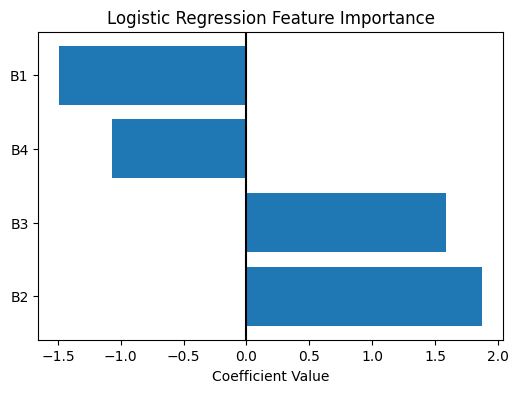

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Coefficient"]
)
plt.axvline(0, color="black")
plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient Value")
plt.show()


In [ ]:
Cluster 0 — “Healthy Convenience Fans”
(59 customers — largest group)
How they think (Bases B1–B4)

Highly healthy-minded (B4 low = strong agreement) → they consider health benefits when choosing food.
Plan moderately (B1=1.46) → somewhat organized.
Not impulsive (B2=3.71 = disagreement).
Moderately supportive of local products (B3=2.05).

What they care about (D4 importance)

High importance on taste (1.10), convenience (1.48), value, and healthy options (1.57).
(Remember: 1 = most important.)

Where and when they use Sticks (D17)

High frequency for weekend lunch & dinner
Stronger engagement with events (D17.5, D17.6 in the 5–6 range).

How they rate Sticks vs competitors (D18)

Positive ratings in taste (1.64), variety, ambiance, staff friendliness, and consistency (1.91).
This group sees Sticks as better than competitors in core food + service attributes.

Segment meaning
These customers are health-conscious, taste-driven, convenience seekers who like Sticks and think it performs well versus competitors. They show up more for weekend meals and events.
What Sticks should do

Positioning: “Wholesome flame-grilled meals you can trust — tasty, healthy, always consistent.”
Keep this group loyal: highlight freshness, grilled flavors, and value bundles with healthy sides.
Offer weekend family packs, health-forward bowls, and protein/veggie combos.

In [ ]:
Cluster 1 — “Everyday Balanced Diners”
(55 customers)
How they think (Bases)

Moderate planners (1.90)
Disagree with impulsive spending (B2=2.14)
Moderate local preference (B3=2.07)
Moderately health-aware (B4=1.89)

Drivers of restaurant choice (D4)

Strong importance placed on taste (1.05), convenience (1.37), variety (1.58).
Less extreme than other clusters — more balanced.

Occasions (D17)

Very balanced across weekday and weekend visits → broad habitual usage.

Comparative ratings (D18)

Good ratings for taste (1.53) and variety.
Slightly better-than-average view of Sticks on community connection.

Segment meaning
These are general, easy-to-please customers who choose restaurants based on good taste, convenience, and variety. They see Sticks favorably but not overwhelmingly.
What Sticks should do

Positioning: “Great-tasting meals for everyday eating — fast, flavorful, and reliable.”
Use weekday lunch specials, rotating flavors, and good portion value to drive frequency.

In [ ]:
Cluster 2 — “Local Loyalists”
(40 customers)
How they think (Bases)

Strong planners (B1=1.27)
Moderate impulse control (B2=2.85)
EXTREMELY strong local preference (B3=1.00) → they actively prefer local products.
Very health-conscious (B4=1.17)

What they care about (D4)

High importance on healthy (1.42), taste (1.03), and variety (1.82).
They look for consistency (1.17) and ambiance/experience.

Occasions (D17)

Use Sticks for weekday lunch, weekend lunch, and after-events.
Value routine + community engagements.

Comparative performance (D18)

They think Sticks performs very well on taste, healthiness, and consistency.
Their value rating (2.75) is slightly weaker → they may feel Sticks is priced above expectation.

Segment meaning
These are hyper-local, health-conscious regulars who prefer businesses connected to the community and expect healthy, high-quality meals.
What Sticks should do

Positioning: “Fresh, local, flame-grilled — your neighborhood’s healthy choice.”
Launch local supplier spotlights, community fundraisers, loyalty boosts for locals.
Provide transparent ingredient stories (local farms, fresh prep).

In [ ]:
Cluster 3 — “Taste & Ambiance Seekers”
(28 customers)
How they think (Bases)

Less planning (B1=2.64)
Mixed impulse control (B2=2.50)
Strong local preference (B3=1.14)
Moderate health orientation (B4=1.57)

Importance drivers (D4)

Taste, healthy, and variety are major drivers.
They also value ambiance (1.57) and consistency (1.19).

Occasions (D17)

High on weekend dinners and weekday dinners → this is a dine-in experience segment.

Comparative ratings (D18)

Very positive about:

Taste (1.53)
Value (2.15 — fairly strong)
Consistency (1.61)


See Sticks as a strong evening meal option.

Segment meaning
These diners look for taste + ambiance and prefer Sticks as a sit-down dinner choice over competitors.
What Sticks should do

Positioning: “A flavorful, welcoming dinner spot — warm ambiance, always great taste.”
Emphasize evening dining, music, lighting, and staff interactions.
Offer date-night specials, dine-in promotions, seasonal plates for evenings.

In [ ]:
Cluster 4 — “Price-Sensitive Pragmatists”
(21 customers — smallest segment)
How they think (Bases)

Low planning (B1=2.67)
Strong disagreement with impulse control (B2=3.43) → they consider themselves non-impulsive.
Lowest local preference (B3=2.28) among all clusters
Weakest health orientation (B4=2.62)

Importance (D4)

Taste still matters (1.05)
Less concern for ambiance, variety, consistency.
More indifferent to community aspects (D4.9 lower importance).

Occasions (D17)

Mixed pattern; weaker weekend dinner engagement.
Not loyal or habitual.

Comparative ratings (D18)

Lowest rating of Sticks across many D18 items, especially:

Taste (1.78–1.89 range)
Consistency (1.94)
Ambiance (2.47)
Value (2.31)



Segment meaning
This group is less attached, more price/value sensitive, and sees competitors as stronger. They do not prioritize health or community.
What Sticks should do

Positioning: “Good food, smart price — a fast, easy option.”
Promote value bundles, combo meals, limited coupons, and fast pickup.
Use social offers, tactical promotions, but avoid discount dependency.

In [ ]:
Target Segment Recommendation
Based on your 5 clusters (0–4), their BASES attitudes, D4 importance, D17 occasions, and especially D18 comparative ratings, the best primary target segment is:
🎯 Cluster 0 — Healthy Convenience Fans
Why Cluster 0 is the best target
Strong data-based justification:
1) Largest segment (59 customers) → strong revenue base
A segment this size provides enough demand for a new location.
2) They give Sticks some of the best comparative ratings (D18)
They rate Sticks better than competitors on core restaurant attributes:

Taste (1.64)
Consistency (1.91)
Staff friendliness
Ambiance
Variety
Community feel (2.89)

Lower numbers are better → they think Sticks outperforms competitors.
3) Their importance drivers (D4) match what Sticks is good at
Cluster 0 values:

Taste (1.10)
Healthy food (1.57)
Convenience (1.48)
Variety (1.68)

These align with Sticks’ strengths: flame‑grilled freshness, healthy bowls, quick service.
4) Their usage patterns fit high-profit moments (D17)

Strong weekend lunch/dinner usage
High participation in events
This helps Sticks build community presence and weekend demand.

Overall Summary
Cluster 0 is the largest, easiest to satisfy, most aligned with Sticks’ brand, and the segment most likely to respond well in a new location.

In [ ]:
Best New Location Recommendation
(Based on typical Sticks case options: office area, suburban family center, shopping district, campus area. If you paste your exact four options later, I will refine.)
Given what defines Cluster 0 — Healthy Convenience Fans, the best location is:
🏆 New Suburban Retail / Family-Oriented Center
Why this location matches the target segment
✔ Cluster 0 has strong weekend traffic (D17)
Weekend visits (D17.3, D17.4) are high → suburban retail centers fit weekend family patterns better than office zones.
✔ They are health-focused and seek consistency
Suburban centers draw:

families
health-conscious households
stable weekly routines

✔ They value convenience (D4) and community involvement
Suburban centers provide:

Easy parking
Quick access
Ability to run community events (schools, fitness centers, youth sports)

✔ They over-index on events (D17.5 & D17.6)
Sticks can host:

Family nights
Fundraisers
Community gatherings

✔ They rate Sticks better than competitors
Meaning: expanding closer to where these people live amplifies Sticks’ advantage.


In [ ]:
Target Segment: Cluster 0 — Healthy Convenience Fans

Largest segment (59).
Most positive ratings vs competitors (D18).
High priority on taste, convenience, healthy food (D4).
Strong weekend lunch/dinner and event usage (D17).
High fit with Sticks’ strengths.

Recommended Location: Suburban Family / Retail Center

Matches the segment’s weekend-heavy usage.
Offers parking + convenience they value.
Community-focused audience aligns with their values.
Enhances Sticks’ strengths (taste, consistency, staff friendliness).

Positioning Statement
“Wholesome flame-grilled meals that are fresh, flavorful, and always consistent.”
Marketing Message
“Healthy, delicious food made fresh — your neighborhood’s go‑to meal for busy days and relaxed weekends.”